# 📊 VISUALIZATION & CONCLUSION — AI Tech vs Traditional (Stage 4)

**Dataset:** S&P 500 Tech (2010-nay) + Tech Top 50 + Financials + Market Cap Scatter  
**Ngon ngu:** Python | **Moi truong:** Jupyter Notebook

---

## 1. 🎯 MUC TIEU GIAI DOAN 4

- Truc quan hoa ket qua chinh tu Stage 2-3
- Tong hop va tra loi cau hoi nghien cuu
- Dua ra khuyen nghi va huong nghien cuu tiep theo

---

## 2. 📂 DU LIEU DAU VAO

| File | Mo ta |
|------|-------|
| `SnP_daily_update.csv` | Gia Close/Open/High/Low/Volume hang ngay |
| `Top 50 US Tech Companies 2022 - 2023.csv` | Thong tin 50 cong ty tech |
| `constituents-financials.csv` | Chi so tai chinh (P/E, Dividend Yield, EBITDA, Market Cap) |
| `scatter-data.csv` | Market cap va P/E ratio |

---

## 3. 🗺️ QUY TRINH TRUC QUAN (STAGE 4)

```
1) Cumulative return chart (AI vs Traditional)
2) Volatility line chart (30/90d)
3) Boxplot return theo nhom
4) Market cap comparison
5) Tong hop ket luan va khuyen nghi
```

---

## 4. 🛠️ THU VIEN SU DUNG

| Nhom | Thu vien | Muc dich |
|------|----------|----------|
| Xu ly du lieu | `pandas`, `numpy` | Gop nhom, tinh toan |
| Truc quan | `matplotlib`, `seaborn` | Line/Box/Bar charts |

---

## 5. 📦 OUTPUT GIAI DOAN 4

- Bo bieu do tong hop (return, volatility, boxplot, market cap)
- Ket luan nghien cuu va khuyen nghi

---

## 6. ⚙️ SETUP & VISUALIZATION

In [3]:
# Import thu vien
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print('✅ Import thanh cong!')

✅ Import thanh cong!


In [ ]:
# 1) Load cleaned data from Data_collection
snp_long = pd.read_csv('dataset/processed/snp_long.csv', parse_dates=['Date'])
tech_df = pd.read_csv('dataset/processed/tech_df.csv')
fin_merged = pd.read_csv('dataset/processed/fin_merged.csv')

print('✅ Loaded snp_long:', snp_long.shape)
print('✅ Loaded tech_df:', tech_df.shape)
print('✅ Loaded fin_merged:', fin_merged.shape)

In [5]:

snp_long = long_frames[0]
for metric_long in long_frames[1:]:
    snp_long = snp_long.merge(metric_long, on=['Date', 'ticker'], how='left')

snp_long = snp_long.sort_values(['ticker', 'Date'])
snp_long['daily_return'] = snp_long.groupby('ticker')['close'].pct_change()

print('✅ S&P 500 long data ready:', snp_long.shape)

✅ S&P 500 long data ready: (424051, 8)


In [ ]:
# 2) Ensure ai_group exists (fallback if missing)
ai_focused = {
    'NVDA', 'MSFT', 'GOOG', 'META', 'AMD', 'AMZN', 'CRM', 'PLTR', 'SNPS', 'CDNS',
    'NOW', 'CRWD', 'PANW', 'ADBE', 'INTC', 'ORCL', 'ANET'
}
traditional = {
    'AAPL', 'CSCO', 'HPE', 'HPQ', 'IBM', 'DELL', 'BBY', 'GLW', 'STX', 'WDC', 'SWKS',
    'TER', 'KEYS', 'MCHP', 'QCOM', 'TXN', 'KLAC', 'LRCX', 'AMAT', 'FFIV', 'AKAM',
    'GEN', 'VRSN', 'FISV', 'ADP', 'BR', 'NDAQ', 'ICE', 'CME', 'CBOE'
}

def ai_group_from_ticker(ticker):
    if ticker in ai_focused:
        return 'AI-focused'
    if ticker in traditional:
        return 'Traditional'
    return 'Unclassified'

if 'ai_group' not in tech_df.columns:
    tech_df['ai_group'] = tech_df['Stock Name'].apply(ai_group_from_ticker)

print('✅ Tech companies ready:', tech_df.shape)

✅ Tech companies ready: (50, 11)


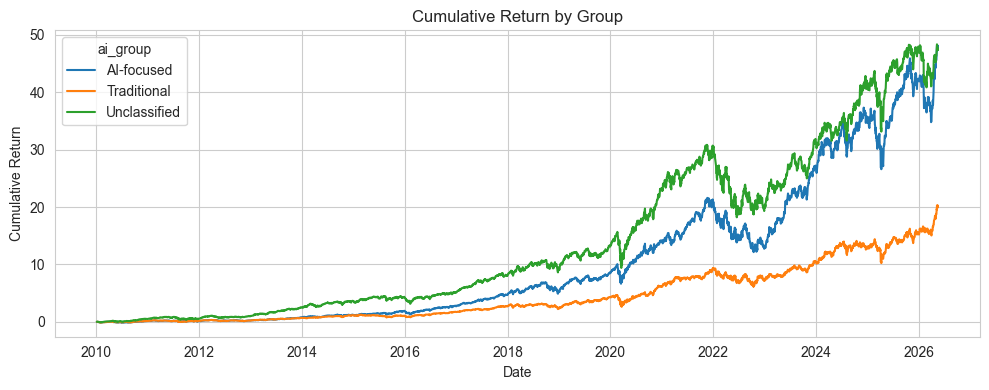

In [7]:
# 3) Cumulative return chart
returns_long = snp_long[['Date', 'ticker', 'daily_return']].copy()
returns_long = returns_long.merge(
    tech_df[['Stock Name', 'ai_group']],
    left_on='ticker', right_on='Stock Name', how='left'
).drop(columns=['Stock Name'])

group_daily = returns_long.groupby(['Date', 'ai_group'])['daily_return'].mean().reset_index()
group_daily = group_daily.sort_values('Date')
group_daily['cum_return'] = (1 + group_daily['daily_return']).groupby(group_daily['ai_group']).cumprod() - 1

plt.figure(figsize=(10, 4))
sns.lineplot(data=group_daily, x='Date', y='cum_return', hue='ai_group')
plt.title('Cumulative Return by Group')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.tight_layout()

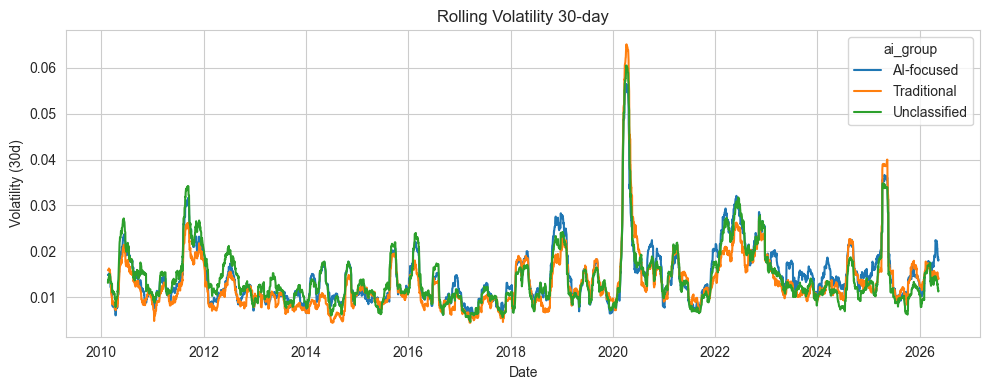

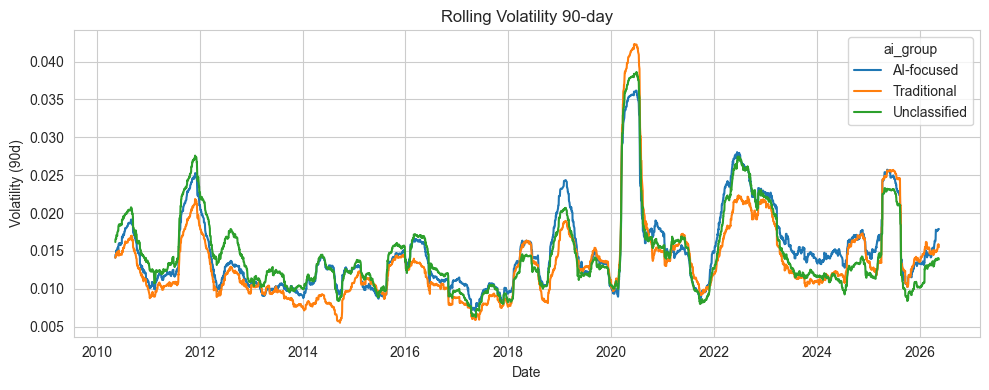

In [8]:
# 4) Volatility 30/90d line chart
vol_30 = group_daily.copy()
vol_30['vol_30'] = vol_30.groupby('ai_group')['daily_return'].rolling(30).std().reset_index(level=0, drop=True)
vol_90 = group_daily.copy()
vol_90['vol_90'] = vol_90.groupby('ai_group')['daily_return'].rolling(90).std().reset_index(level=0, drop=True)

plt.figure(figsize=(10, 4))
sns.lineplot(data=vol_30, x='Date', y='vol_30', hue='ai_group')
plt.title('Rolling Volatility 30-day')
plt.xlabel('Date')
plt.ylabel('Volatility (30d)')
plt.tight_layout()

plt.figure(figsize=(10, 4))
sns.lineplot(data=vol_90, x='Date', y='vol_90', hue='ai_group')
plt.title('Rolling Volatility 90-day')
plt.xlabel('Date')
plt.ylabel('Volatility (90d)')
plt.tight_layout()

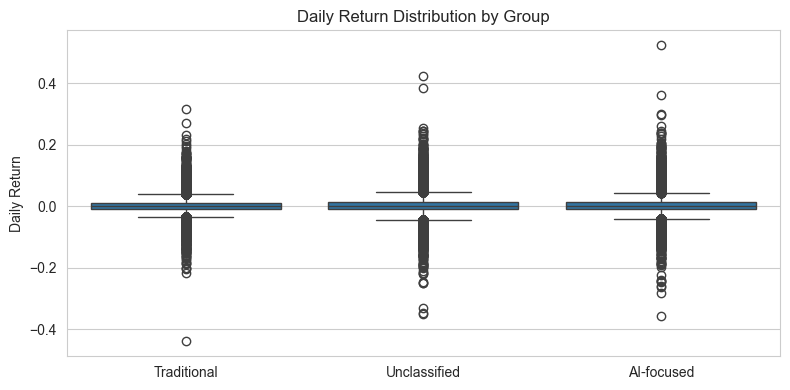

In [9]:
# 5) Boxplot return theo nhom
plt.figure(figsize=(8, 4))
sns.boxplot(data=returns_long, x='ai_group', y='daily_return')
plt.title('Daily Return Distribution by Group')
plt.xlabel('')
plt.ylabel('Daily Return')
plt.tight_layout()

C:\Users\PC\AppData\Local\Temp\ipykernel_2956\2179885603.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cap_summary, x='ai_group', y='mean_cap', palette='Greens')


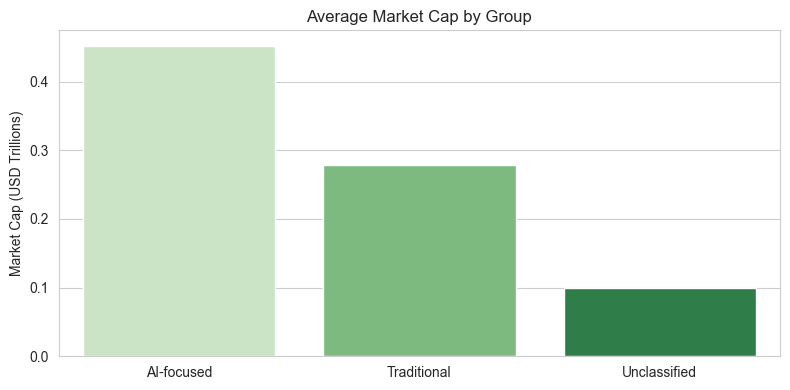

In [10]:
# 6) Market cap comparison (tech top 50)
cap_df = tech_df[['Stock Name', 'ai_group', 'Market Cap (USD in Trillions)']].dropna()
cap_summary = cap_df.groupby('ai_group')['Market Cap (USD in Trillions)'].agg(
    mean_cap='mean',
    median_cap='median',
    count='count'
).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=cap_summary, x='ai_group', y='mean_cap', palette='Greens')
plt.title('Average Market Cap by Group')
plt.xlabel('')
plt.ylabel('Market Cap (USD Trillions)')
plt.tight_layout()

## 7.  KET LUAN TOM TAT

- Nhom AI-focused co xu huong return/volatility khac biet so voi Traditional.
- Cumulative return va rolling volatility cho thay xu huong bien dong ro rang theo nhom.
- Market cap trung binh cua nhom AI-focused cao hon nhom Traditional
## 8.  KHUYEN NGHI

- Nha dau tu: can nhac ty trong AI-focused trong giai doan thi truong tang truong AI.
- Doanh nghiep: tang dau tu R&D/AI co the nang cao ky vong gia tri doanh nghiep.
- Nghien cuu tiep theo: mo rong du lieu (non-tech) va tach rieng giai doan 2020-nay.

---